In [33]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

FIG_DIR = "../outputs/standardized_figures/"
TAB_DIR = "../outputs/standardized_tables/"

term_labels = {
    "Intercept": "Intercept",
    "log_median_household_income": "Log median household income",
    "log_median_housing_value": "Log median housing value",
    "log_pop_density": "Log population density",
    "poverty_rate": "Poverty rate",
    "pct_bachelors_plus": "% Bachelor's+",
    "pct_black": "% Black",
    "pct_hispanic": "% Hispanic",
    "pct_asian": "% Asian",
    "cdd65_2023": "Cooling degree days",
    "hdd65_2023": "Heating degree days",
    "cdd65_2023": "Cooling degree days",
    "hdd65_2023": "Heating degree days",
    "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
    "wind_ws10m_mean_2023": "Wind speed (10m)",
    "wind_ws50m_mean_2023": "Wind speed (50m)",
    "log_kwh": "Log annual electricity demand",
    "y_pv": "Solar PV adoption",
    "y_chargers": "EV charger adoption",
}

outcome_display = {
    "y_pv": "Solar PV",
    "y_chargers": "EV Chargers",
    "y_storage": "Storage",
    "y_wind_mw": "Wind MW",
    "any_turbines": "Any turbines",
}

paper_main_models = {
    "y_pv": "Model 1 baseline (climate controls)",
    "y_chargers": "Model 1 baseline (climate controls)",
    "y_storage": "Model 1 baseline (climate controls)",
    "y_wind_mw": "Model 1 baseline (climate controls)",
    "any_turbines": "Model 1 baseline (climate controls)",
}

paper_robustness_models = [
    "Model 1 baseline (climate controls)",
    # "Model 1 baseline (no climate controls)",
    "Model 2 (add bachelors)",
    "Model 2 (add housing value)",
    "Model 4 interactions (centered)",
    "Model 5C clustered SEs by county",
    "Model 7 (infrastructure controls, outcome-safe)",
    "Model 8 add demand proxy",
]

terms_main = [
    "log_median_household_income",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "poverty_rate",
]

terms_heatmap = [
    "log_median_household_income",
    "pct_black",
    "pct_hispanic",
    "pct_asian",
    "poverty_rate",
]

robustness_terms_by_outcome = {
    "y_pv": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "ghi_mean_kwh_m2_day_2023",
    ],
    "y_chargers": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "cdd65_2023",
        "hdd65_2023",
    ],
    "y_storage": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "cdd65_2023",
        "hdd65_2023",
    ],
    "y_wind_mw": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "wind_ws50m_mean_2023",
    ],
    "any_turbines": [
        "log_median_household_income",
        "pct_black",
        "pct_hispanic",
        "poverty_rate",
        "wind_ws50m_mean_2023",
    ],
}

heatmap_models = [
    "Model 1 baseline (climate controls)",
    "Model 2 (add bachelors)",
    "Model 8 add demand proxy",
]

heatmap_outcomes = [
    "y_pv",
    "y_chargers",
    "y_storage",
    "y_wind_mw",
    "any_turbines",
]

legend_handles = [
    Line2D([0], [0], color="C0", marker="o", linestyle="-", label="Coefficient (95% CI)"),
    Line2D([0], [0], color="black", linestyle="--", label="Zero effect"),
    Line2D([0], [0], color="black", marker="$*$", linestyle="None", markersize=10,
           label="Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, · p < 0.10")
]

In [34]:

def stars_from_pval(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.10:
        return "·"
    return ""

def parse_filename(path):
    fname = os.path.basename(path).replace(".csv", "")
    if " | " in fname:
        outcome, model = fname.split(" | ", 1)
    else:
        outcome, model = fname, "Unknown"
    return outcome.strip(), model.strip()

def load_coef_csv(path):
    outcome, model = parse_filename(path)
    df = pd.read_csv(path)

    first_col = df.columns[0]
    if first_col == "Unnamed: 0":
        df = df.rename(columns={"Unnamed: 0": "term"})
    elif first_col != "term":
        df = df.rename(columns={first_col: "term"})

    rename_map = {
        "Coef.": "coef",
        "Std.Err.": "std_err",
        "P>|z|": "pval",
        "P>|t|": "pval",
        "[0.025": "conf_low",
        "0.025": "conf_low",
        "0.975]": "conf_high",
        "0.975": "conf_high",
    }
    df = df.rename(columns=rename_map)

    keep = ["term", "coef", "std_err", "pval", "conf_low", "conf_high"]
    df = df[keep].copy()
    df["outcome"] = outcome
    df["model"] = model
    df["term_label"] = df["term"].map(lambda x: term_labels.get(x, x))
    df["stars"] = df["pval"].map(stars_from_pval)
    return df

In [35]:
def plot_dot_whisker_from_csvs(all_coefs, main_models, terms_keep, outcome_display, save_path=None):
    outcomes = list(main_models.keys())
    fig, axes = plt.subplots(len(outcomes), 1, figsize=(11, 12), sharex=True)
    if len(outcomes) == 1:
        axes = [axes]

    for ax, outcome in zip(axes, outcomes):
        model = main_models[outcome]
        sub = all_coefs[
            (all_coefs["outcome"] == outcome) &
            (all_coefs["model"] == model) &
            (all_coefs["term"].isin(terms_keep))
        ].copy()

        sub["term"] = pd.Categorical(sub["term"], categories=terms_keep, ordered=True)
        sub = sub.sort_values("term")

        y = np.arange(len(sub))
        ax.errorbar(
            x=sub["coef"],
            y=y,
            xerr=[sub["coef"] - sub["conf_low"], sub["conf_high"] - sub["coef"]],
            fmt="o",
            capsize=3
        )
        ax.axvline(0, linestyle="--", linewidth=1)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["term_label"])
        ax.set_title(outcome_display.get(outcome, outcome))
        if ax is axes[-1]:
            ax.set_xlabel("Coefficient")
        else:
            ax.set_xlabel("")
        span = sub["conf_high"].max() - sub["conf_low"].min()
        offset = 0.02 * (span if span > 0 else 1)
        for i, (_, row) in enumerate(sub.iterrows()):
            ax.text(row["conf_high"] + offset, i, row["stars"], va="center", fontsize=10)

    fig.suptitle("Coefficient comparison across outcomes", y=0.995, fontsize=14)

    fig.text(
        0.45, 0.95,
        "Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, · p < 0.10",
        ha="center",
        va="top",
        fontsize=10
    )

    fig.subplots_adjust(top=0.88, bottom=0.18)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [36]:
from matplotlib.lines import Line2D

def plot_stability_from_csvs(all_coefs, outcome, models_keep, terms_keep, outcome_display, save_path=None):
    sub = all_coefs[
        (all_coefs["outcome"] == outcome) &
        (all_coefs["model"].isin(models_keep)) &
        (all_coefs["term"].isin(terms_keep))
    ].copy()

    sub["model"] = pd.Categorical(sub["model"], categories=models_keep, ordered=True)

    fig, axes = plt.subplots(len(terms_keep), 1, figsize=(11, 8), sharex=True)
    if len(terms_keep) == 1:
        axes = [axes]

    for ax, term in zip(axes, terms_keep):
        s = sub[sub["term"] == term].copy()
        model_to_x = {m: i for i, m in enumerate(models_keep)}
        s["x"] = s["model"].map(model_to_x)
        s = s.sort_values("x")

        ax.errorbar(
            x=s["x"],
            y=s["coef"],
            yerr=[s["coef"] - s["conf_low"], s["conf_high"] - s["coef"]],
            fmt="o-",
            capsize=3
        )
        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_ylabel(term_labels.get(term, term), rotation=45, labelpad=40)

        for _, row in s.iterrows():
            ax.text(row["x"], row["conf_high"], row["stars"], ha="center", va="bottom", fontsize=9)

    axes[-1].set_xticks(np.arange(len(models_keep)))
    axes[-1].set_xticklabels(models_keep, rotation=35, ha="right")

    plt.suptitle(
        f"Coefficient stability across specifications: {outcome_display.get(outcome, outcome)}",
        y=0.995,
        fontsize=14
    )

    fig.text(
        -0.05, 0.5,
        "Coefficient estimate",
        ha="center",
        va="center",
        rotation=90,
        fontsize=11
    )
    fig.text(
        0.45, 0.95,
        "Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, · p < 0.10",
        ha="center",
        va="top",
        fontsize=10
    )
    fig.subplots_adjust(top=0.88, bottom=0.18)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


In [37]:

def plot_heatmap_from_csvs(all_coefs, outcomes_keep, models_keep, terms_keep, outcome_display, save_path=None):
    sub = all_coefs[
        (all_coefs["outcome"].isin(outcomes_keep)) &
        (all_coefs["model"].isin(models_keep)) &
        (all_coefs["term"].isin(terms_keep))
    ].copy()

    sub["col_label"] = sub["outcome"].map(lambda x: outcome_display.get(x, x)) + " | " + sub["model"]

    coef_mat = sub.pivot_table(index="term", columns="col_label", values="coef").reindex(terms_keep)
    pval_mat = sub.pivot_table(index="term", columns="col_label", values="pval").reindex(terms_keep)

    vmax = np.nanmax(np.abs(coef_mat.values))
    if np.isnan(vmax) or vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(
        coef_mat.values,
        aspect="auto",
        cmap="coolwarm",
        norm=mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    )

    ax.set_xticks(np.arange(coef_mat.shape[1]))
    ax.set_xticklabels(coef_mat.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(coef_mat.shape[0]))
    ax.set_yticklabels([term_labels.get(t, t) for t in coef_mat.index])

    for i in range(coef_mat.shape[0]):
        for j in range(coef_mat.shape[1]):
            p = pval_mat.iloc[i, j]
            txt = "" if pd.isna(p) else stars_from_pval(p)
            ax.text(j, i, txt, ha="center", va="center", fontsize=9)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Signed coefficient")
    ax.set_title("Signed coefficient heatmap with significance annotations")

    fig.text(
        0.45, 0.95,
        "Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, · p < 0.10",
        ha="center",
        va="top",
        fontsize=10
    )

    fig.subplots_adjust(top=0.88, bottom=0.18)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [38]:
coef_paths = sorted(glob.glob(os.path.join(TAB_DIR, "*.csv")))
coef_paths = [p for p in coef_paths if os.path.basename(p) != "y_storage_model_comparison.csv"]

frames = []
for p in coef_paths:
    try:
        frames.append(load_coef_csv(p))
    except Exception as e:
        print(f"Skipping {os.path.basename(p)}: {e}")

all_coefs = pd.concat(frames, ignore_index=True)

print(all_coefs.shape)
print(all_coefs[["outcome", "model"]].drop_duplicates().sort_values(["outcome", "model"]).to_string(index=False))

(1756, 10)
           outcome                                           model
      any_turbines                                      + chargers
      any_turbines                                            + pv
      any_turbines                                 + pv + chargers
      any_turbines                      Model 1 baseline (CDD+HDD)
      any_turbines             Model 1 baseline (climate controls)
      any_turbines          Model 1 baseline (no climate controls)
      any_turbines                         Model 2 (add bachelors)
      any_turbines                     Model 2 (add housing value)
      any_turbines                            Model 3A (HDD + CDD)
      any_turbines                            Model 3B (temp only)
      any_turbines                             Model 3C (GHI only)
      any_turbines                 Model 4 interactions (centered)
      any_turbines                Model 4R interactions (centered)
      any_turbines                              Mod

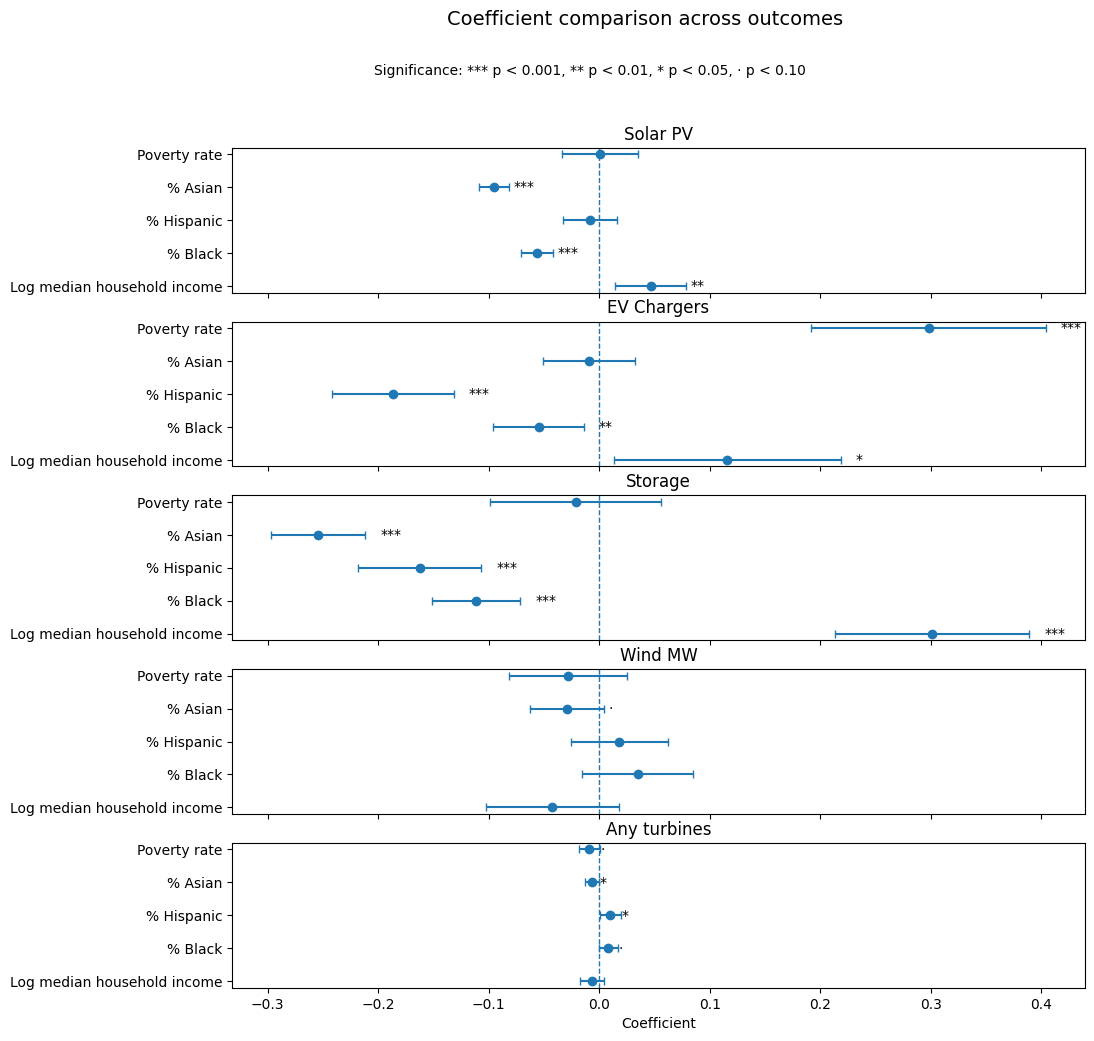

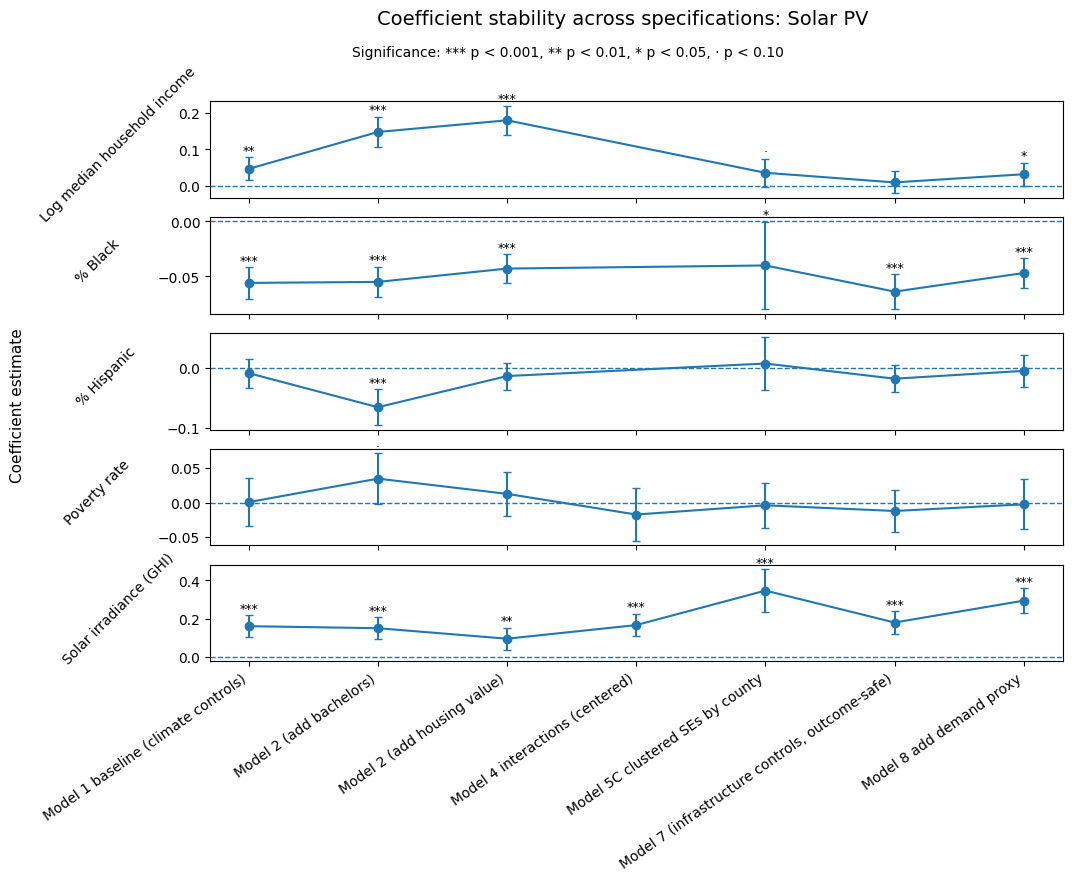

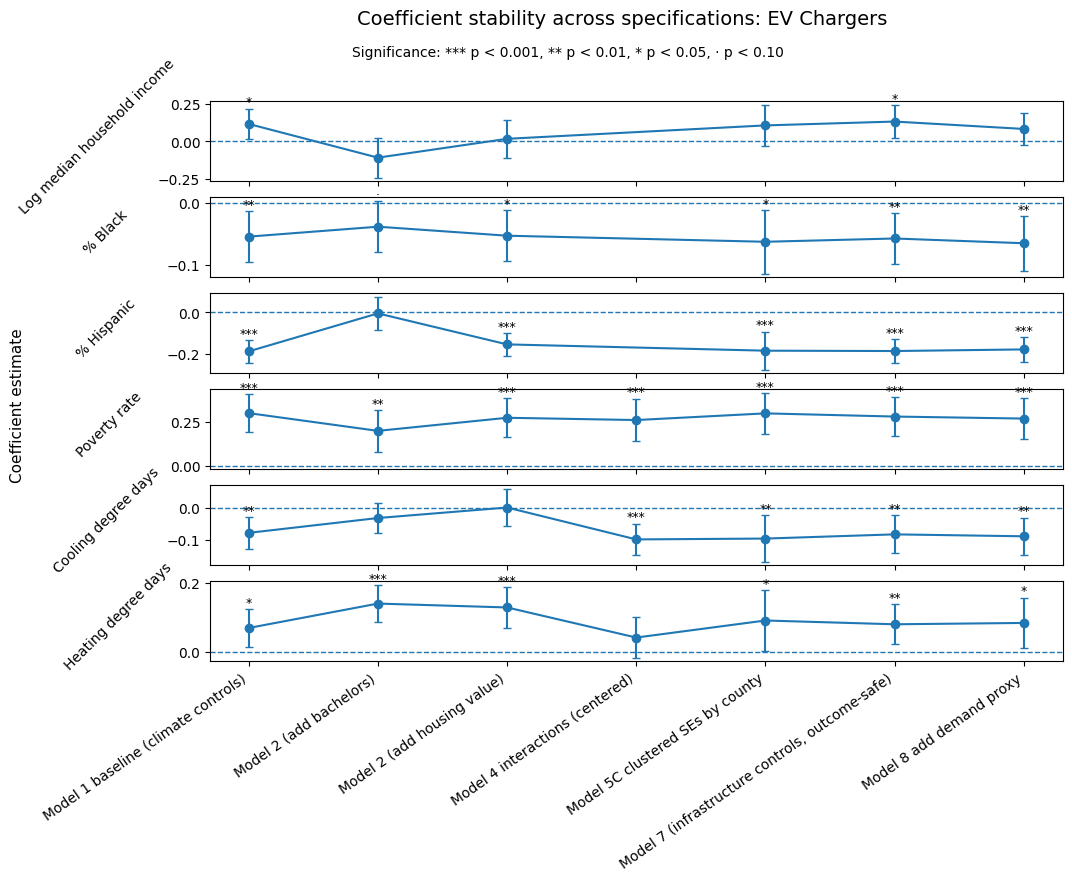

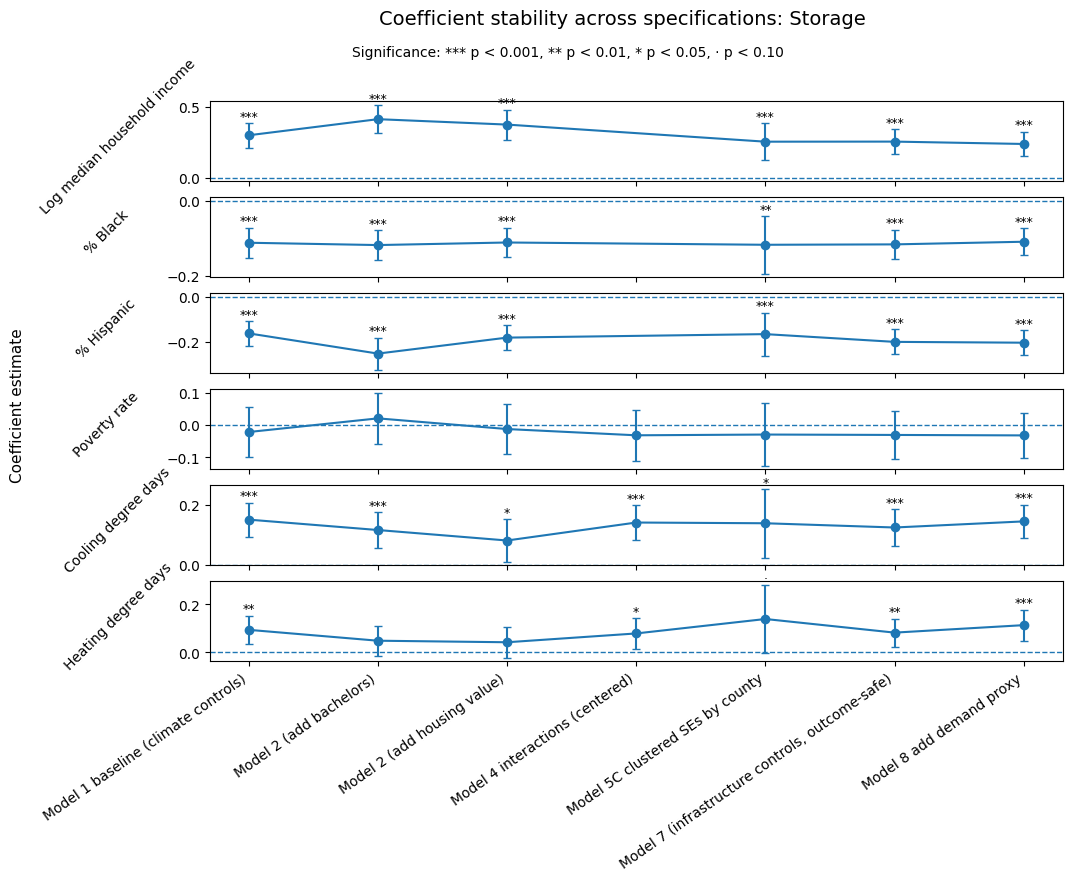

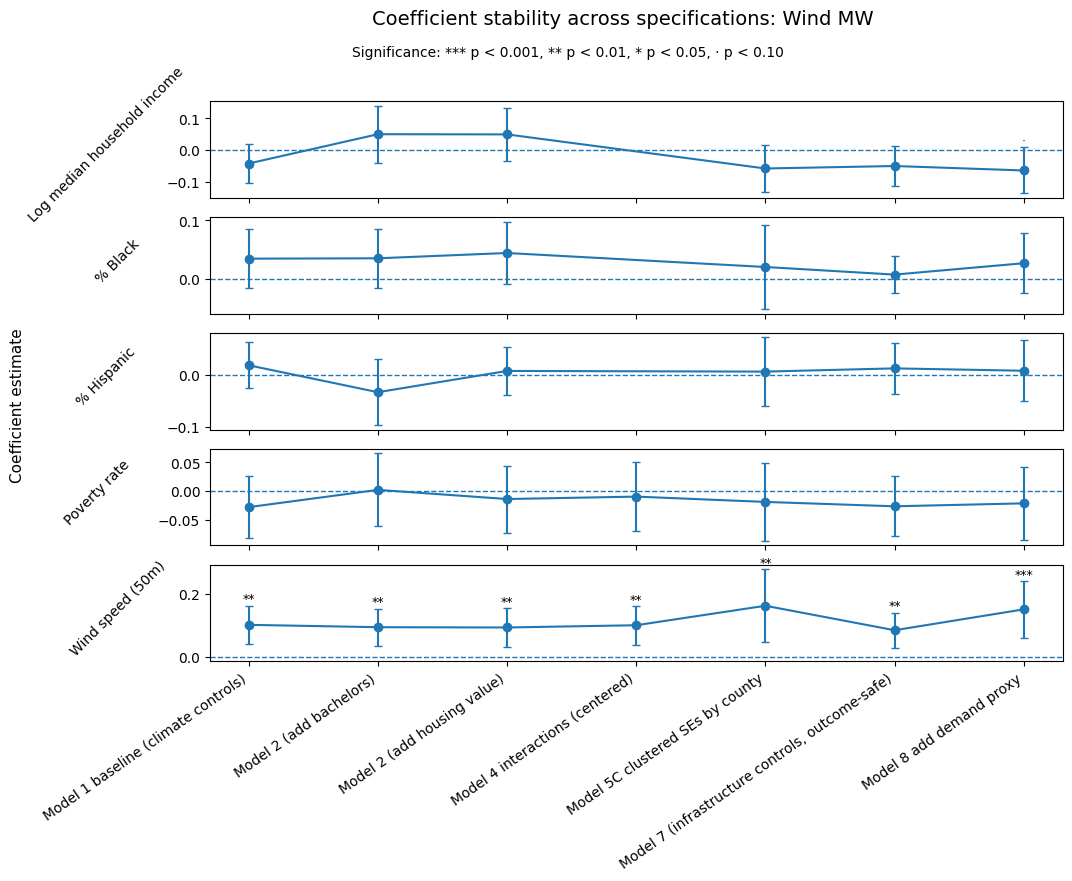

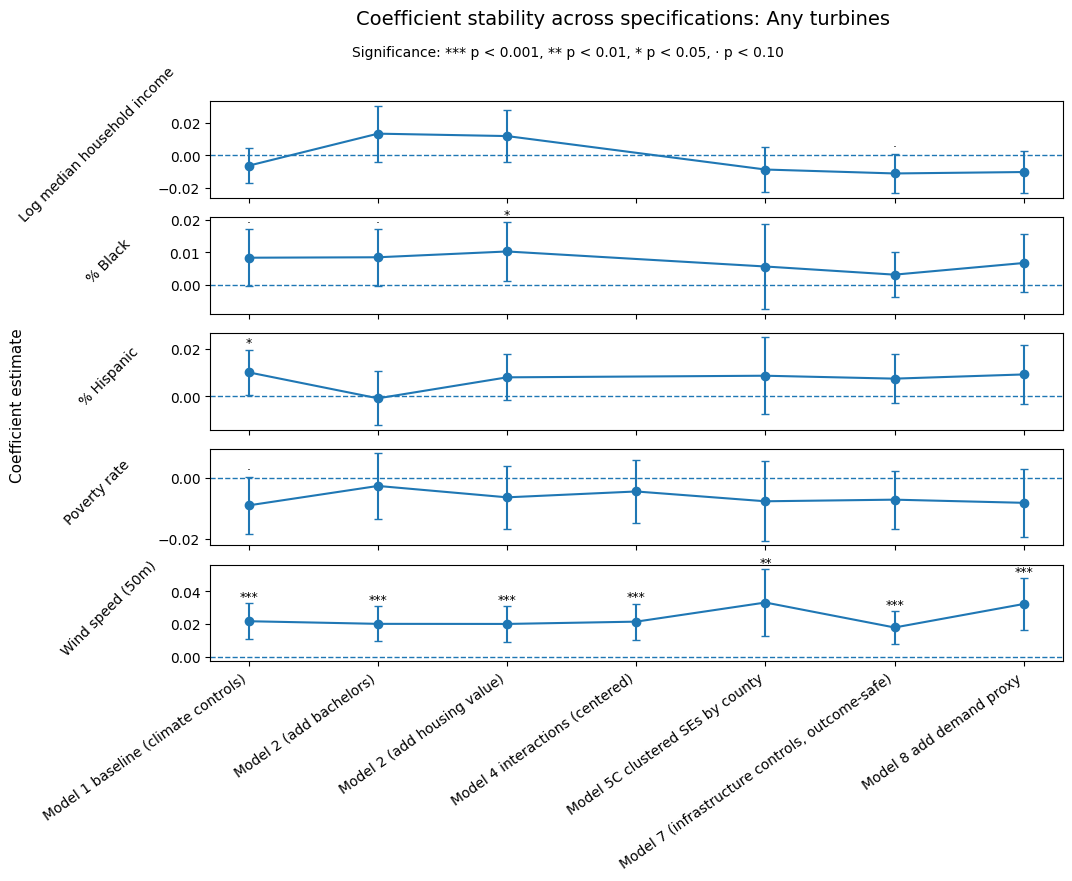

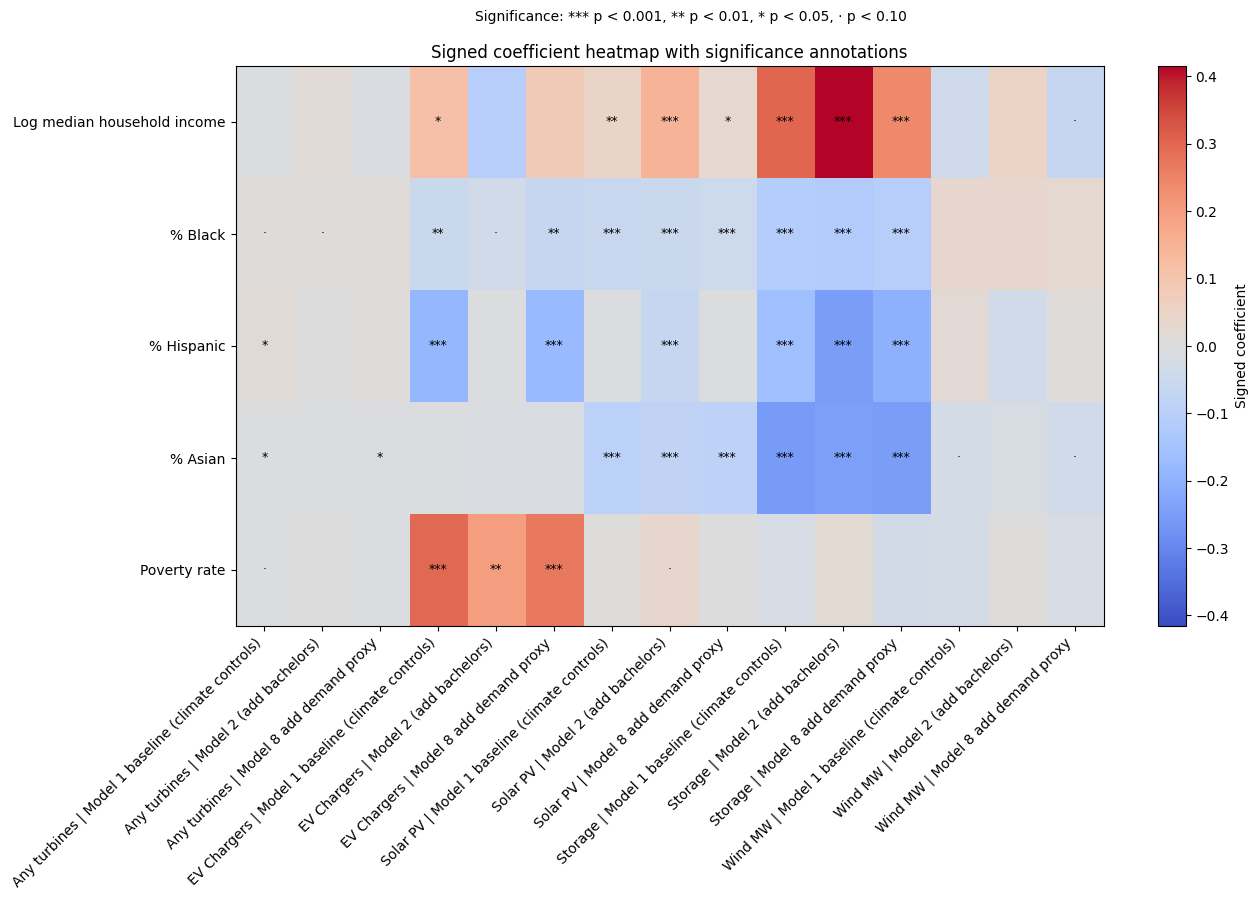

In [39]:
# 1) Main figure: dot-whisker across outcomes
plot_dot_whisker_from_csvs(
    all_coefs=all_coefs,
    main_models=paper_main_models,
    terms_keep=terms_main,
    outcome_display=outcome_display,
    save_path=FIG_DIR + "main_dot_whisker_across_outcomes.png"
)

# 2) Robustness figure: one per outcome
for outcome in heatmap_outcomes:
    plot_stability_from_csvs(
        all_coefs=all_coefs,
        outcome=outcome,
        models_keep=paper_robustness_models,
        terms_keep=robustness_terms_by_outcome[outcome],
        outcome_display=outcome_display,
        save_path=FIG_DIR + f"{outcome}_robustness.png"
    )

# 3) Appendix figure: signed coefficient / p-value heatmap
plot_heatmap_from_csvs(
    all_coefs=all_coefs,
    outcomes_keep=heatmap_outcomes,
    models_keep=heatmap_models,
    terms_keep=terms_heatmap,
    outcome_display=outcome_display,
    save_path=FIG_DIR + "coef_heatmap_appendix.png"
)

Commerical chargers could skew the poverty rate coefficient.


In [40]:
# term_labels = {
#     "cdd65_2023": "Cooling degree days",
#     "hdd65_2023": "Heating degree days",
#     "ghi_mean_kwh_m2_day_2023": "Solar irradiance (GHI)",
#     "wind_ws10m_mean_2024": "Wind speed (10m)",
#     "wind_ws50m_mean_2024": "Wind speed (50m)",
#     "poverty_rate": "Poverty rate",
#     "pct_bachelors_plus": "% Bachelor's+",
#     "pct_black": "% Black",
#     "pct_hispanic": "% Hispanic",
#     "pct_asian": "% Asian",
#     "log_median_household_income": "Log median household income",
#     "log_median_housing_value": "Log median housing value",
#     "log_pop_density": "Log population density",
#     "log_kwh": "Log annual electricity demand",
#     "y_pv": "Solar PV adoption",
#     "y_chargers": "EV charger adoption",
#     "y_storage": "Storage adoption",
#     "y_wind_mw": "Wind capacity",
#     "y_turbines": "Wind turbine count"
# }
